In [6]:
import gymnasium as gym
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import pandas as pd
import seaborn as sns

n step sarsa

In [19]:
EPISODES = 250000
GAMMA = 1.0
ALPHA = 0.15
EPSILON = 0.05
N = 4

env = gym.make("Blackjack-v1", sab=False)

eps_greedy = lambda q_vals, eps: np.random.randint(len(q_vals)) if np.random.rand() < eps else np.argmax(q_vals)
def state_to_idx(s): return s[0]-1, s[1]-1, s[2]

#calculates sum of n rewards
def n_step_return(r_t, tau, T, gamma, n):
    g = 0.0
    for i in range(tau + 1, min(tau + n, T) + 1):
        g += (gamma ** (i - tau - 1)) * r_t[i % (n + 1)]
    return g

#init q
q = np.zeros((21, 10, 2, 2))

wins = []
for episode in range(EPISODES):
    #init s, a, r w/ index mod n+1
    s_t = [None] * (N + 1)
    a_t = [None] * (N + 1)
    r_t = [0.0] * (N + 1)

    #init s
    s, _ = env.reset()
    s1, s2, s3 = state_to_idx(s)

    #a from eps greedy
    a = eps_greedy(q[s1, s2, s3], EPSILON)

    s_t[0] = (s1, s2, s3)
    a_t[0] = a

    t = 0
    T = float('inf')
    while True:
        #while t not terminated, get rewards and next step
        if t < T:
            #do a, see s_n, r
            s_n, r, term, trunc, _ = env.step(a)
            r_t[(t + 1) % (N + 1)] = r

            #if reach terminal
            if term or trunc:
                wins.append(r > 0)
                T = t + 1
            #if not reach terminal
            else:
                s1_n, s2_n, s3_n = state_to_idx(s_n)
                
                #a from eps greedy
                a_n = eps_greedy(q[s1_n, s2_n, s3_n], EPSILON)
                
                #store a and s, move forward
                s_t[(t + 1) % (N + 1)] = (s1_n, s2_n, s3_n)
                a_t[(t + 1) % (N + 1)] = a_n
                s1, s2, s3 = s1_n, s2_n, s3_n
                a = a_n

        tau = t - N + 1
        if tau >= 0:
            s1_t, s2_t, s3_t = s_t[tau % (N + 1)]
            a_tau = a_t[tau % (N + 1)]

            #returns in N steps preceding t
            g = n_step_return(r_t, tau, T, GAMMA, N)
            #if 
            if tau + N < T:
                s1_b, s2_b, s3_b = s_t[(tau + N) % (N + 1)]
                a_b = a_t[(tau + N) % (N + 1)]
                #udpate bootstrap
                g += (GAMMA ** N) * q[s1_b, s2_b, s3_b, a_b]
            #update q
            q[s1_t, s2_t, s3_t, a_tau] += ALPHA * (g - q[s1_t, s2_t, s3_t, a_tau])

        if tau == T - 1:
            break

        t += 1

env.close()


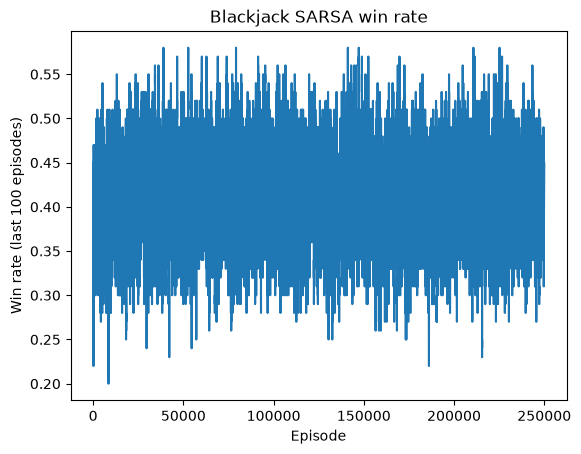

In [20]:
window = 100
win_rate = np.convolve(wins, np.ones(window) / window, mode='valid')

plt.plot(win_rate)
plt.xlabel('Episode')
plt.ylabel(f'Win rate (last {window} episodes)')
plt.title('Blackjack SARSA win rate')
plt.show()

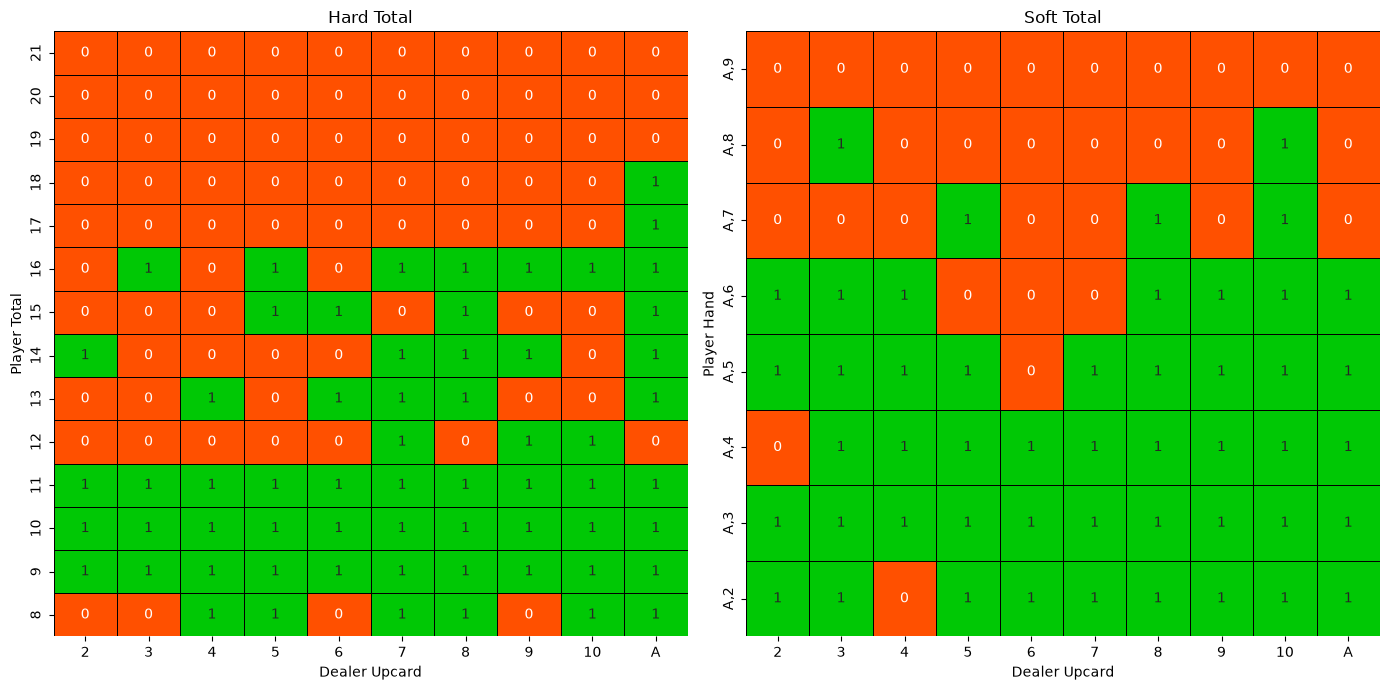

In [21]:

pink = '#FF5000' 
green = '#00C805' 
action_cmap = ListedColormap([pink, green])

dealer_upcards = [(i, str(i)) for i in range(2, 11)] + [(1, 'A')]

hard_table = []
soft_table = []
for player_sum in range(8, 22):
    pi = player_sum - 1
    for dealer_up, dealer_label in dealer_upcards:
        di = dealer_up - 1
        hard_table.append({
            'Player': player_sum,
            'Dealer': dealer_label,
            'Action': np.argmax(q[pi, di, 0]),
        })

for player_sum in range(13, 21):
    pi = player_sum - 1
    hand = f"A,{player_sum - 11}"
    for dealer_up, dealer_label in dealer_upcards:
        di = dealer_up - 1
        soft_table.append({
            'Player': hand,
            'Dealer': dealer_label,
            'Action': np.argmax(q[pi, di, 1]),
        })

col_order = [str(i) for i in range(2, 11)] + ['A']
soft_hand_order = [f"A,{i}" for i in range(9, 1, -1)]
hard_pivot = pd.DataFrame(hard_table).pivot(index='Player', columns='Dealer', values='Action')[col_order].sort_index(ascending=False)
soft_pivot = pd.DataFrame(soft_table).pivot(index='Player', columns='Dealer', values='Action')[col_order].reindex(soft_hand_order)

plt.figure(figsize=(14, 7))
plt.subplot(1, 2, 1)
sns.heatmap(hard_pivot, cmap=action_cmap, cbar=False,
            linewidths=.5, linecolor='black', annot=True, fmt='d')
plt.title('Hard Total')
plt.xlabel('Dealer Upcard')
plt.ylabel('Player Total')

plt.subplot(1, 2, 2)
sns.heatmap(soft_pivot, cmap=action_cmap, cbar=False,
            linewidths=.5, linecolor='black', annot=True, fmt='d')
plt.title('Soft Total')
plt.xlabel('Dealer Upcard')
plt.ylabel('Player Hand')

plt.tight_layout()
plt.show()